Tittle and Intent:- 

# SnapML Preprocessing Observability — Demo

This notebook demonstrates how preprocessing assumptions exported by **SnapML**
can be monitored, explained, and validated **without retraining models** or
re-executing preprocessing logic.

All results shown here are derived **only from the SnapML preprocessing contract**
and controlled inference-time experiments.


## What is under evaluation

We evaluate **preprocessing behavior**, not model accuracy.

Specifically:
- Feature ordering assumptions
- Category coverage in OneHotEncoding
- Normalization behavior under scale changes
- Failure modes: silent vs loud

Excluded by design:
- Model training
- Accuracy / AUC
- Feature inference
- Schema reconstruction


comparison table

In [2]:
import json
from pathlib import Path

SNAPSHOT_DIR = Path("snapshot_reports")

def load_snapshot(name):
    with open(SNAPSHOT_DIR / name) as f:
        return json.load(f)

reports = {
    "Baseline": load_snapshot("baseline.json"),
    "Unseen Categories": load_snapshot("drift_unseen_categories.json"),
    "Categorical Sparsity": load_snapshot("drift_categorical_sparsity.json"),
    "Numeric Scale Drift": load_snapshot("numeric_scale_drift.json"),
    "Column Shuffle (Guarded)": load_snapshot("drift_column_shuffle.json"),
    "Column Shuffle (Unguarded)": load_snapshot("column_shuffle_unguarded.json"),
}


In [3]:
import pandas as pd

rows = []

for name, report in reports.items():
    if "metrics" in report:
        rows.append({
            "Experiment": name,
            "Unseen Category Rate": report["metrics"].get("unseen_category_rate"),
            "Categorical Sparsity Rate": report["metrics"].get("categorical_sparsity_rate"),
            "Norm Anomaly Rate": report["metrics"].get("norm_anomaly_rate"),
            "Alerts": len(report.get("alerts", [])),
            "Status": "OK"
        })
    else:
        rows.append({
            "Experiment": name,
            "Unseen Category Rate": None,
            "Categorical Sparsity Rate": None,
            "Norm Anomaly Rate": None,
            "Alerts": None,
            "Status": "CONTRACT VIOLATION"
        })

df = pd.DataFrame(rows)
df


,Experiment,Unseen Category Rate,Categorical Sparsity Rate,Norm Anomaly Rate,Alerts,Status
0,Baseline,0.0,0.0,0.0,0.0,OK
1,Unseen Categories,1.0,0.0,0.0,1.0,OK
2,Categorical Sparsity,1.0,0.0,0.0,1.0,OK
3,Numeric Scale Drift,0.0,0.0,0.0,0.0,OK
4,Column Shuffle (Guarded),0.0,0.0,0.0,0.0,OK
5,Column Shuffle (Unguarded),NaN,NaN,NaN,NaN,CONTRACT VIOLATION


## Fail-Silent vs Fail-Loud Behavior

Not all preprocessing failures are equal.

**Fail-Silent**
- Unseen categories
- Sparsity explosions
- Model continues running
- Accuracy may degrade slowly

**Fail-Loud**
- Column order mismatch
- Contract violation
- Inference halted immediately

SnapML-aware observability allows us to detect both.


In [4]:
df[["Experiment", "Unseen Category Rate"]]


,Experiment,Unseen Category Rate
0,Baseline,0.0
1,Unseen Categories,1.0
2,Categorical Sparsity,1.0
3,Numeric Scale Drift,0.0
4,Column Shuffle (Guarded),0.0
5,Column Shuffle (Unguarded),NaN


<Axes: title={'center': 'Unseen Category Rate by Experiment'}, xlabel='Experiment'>

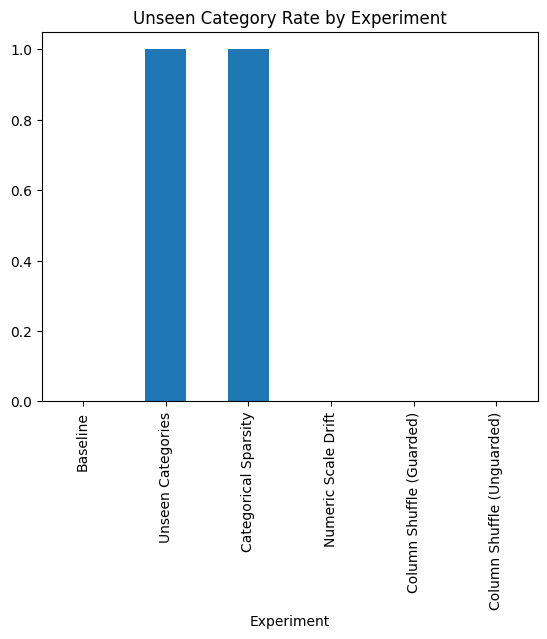

In [9]:
import matplotlib.pyplot

df.set_index("Experiment")["Unseen Category Rate"].plot(kind="bar", title="Unseen Category Rate by Experiment")


## Why Numeric Scale Drift Shows Zero Alerts

Numeric features were L2-normalized during training.

Scaling raw inputs by a constant factor:
- does not violate the normalization assumption
- produces equivalent normalized vectors

This is an example of **benign data drift**.

The system correctly does **not** raise an alert.


## Column Order Drift: Guarded vs Unguarded

Two experiments simulate the same bug:
columns arrive in the wrong order.

- **With SnapML-aware alignment**  
  Drift is neutralized before inference.

- **Without alignment**  
  The system fails loudly due to contract violation.

This demonstrates that:
observability **and** alignment must work together.


In [10]:
reports["Column Shuffle (Unguarded)"]


{'status': 'contract_violation',
 'error_type': 'ValueError',
 'error_message': 'Inference data column order does not match SnapML preprocessing contract. Numeric indices refer to non-numeric values.'}

## Key Takeaways

- Preprocessing is a stateful system
- SnapML exports are enforceable contracts
- Some drift is harmless, some is dangerous
- Accuracy metrics alone are insufficient
- Contract-aware observability improves safety

This demo shows how preprocessing can be:
observable, explainable, and auditable.


## What This Enables

- Production preprocessing audits
- Early detection of silent failures
- Safer SnapML deployment pipelines
- Compliance and governance workflows

All without retraining models or re-running preprocessing.
